In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.model_selection import GridSearchCV
import warnings
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('processed_feature_selected (1).csv')

In [29]:
# Feature Engineering Section
print("Starting Feature Engineering...")

# 1. Create binary target from health_score (healthy if health_score > median)
median_health = df['health_score'].median()
df['healthy'] = np.where(df['health_score'] > median_health, 1, 0)

Starting Feature Engineering...


In [30]:
# 2. Drop unnecessary columns: title (text), fat_level (redundant with dummies), health_score (used for target)
df_engineered = df.drop(['title', 'fat_level', 'health_score'], axis=1)

In [31]:
# 3. Create additional interaction features
# Pairwise interactions between numerical features
df_engineered['fat_calories_interact'] = df_engineered['fat'] * df_engineered['calories']
df_engineered['protein_sodium_interact'] = df_engineered['protein'] * df_engineered['sodium']
df_engineered['fat_protein_interact'] = df_engineered['fat'] * df_engineered['protein']
df_engineered['calories_sodium_interact'] = df_engineered['calories'] * df_engineered['sodium']
df_engineered['rating_fat_interact'] = df_engineered['rating'] * df_engineered['fat']
df_engineered['rating_calories_interact'] = df_engineered['rating'] * df_engineered['calories']

# Interactions with binary features
df_engineered['fat_high_fiber_interact'] = df_engineered['fat'] * df_engineered['high fiber']
df_engineered['calories_fat_level_medium_interact'] = df_engineered['calories'] * df_engineered['fat_level_medium']
df_engineered['calories_fat_level_high_interact'] = df_engineered['calories'] * df_engineered['fat_level_high']
df_engineered['protein_high_fiber_interact'] = df_engineered['protein'] * df_engineered['high fiber']

In [32]:
# 4. Polynomial features for key numerical columns (degree 2 for non-linearity)
poly = PolynomialFeatures(degree=2, include_bias=False)
numerical_cols = ['rating', 'fat', 'calories', 'protein', 'sodium']
poly_features = poly.fit_transform(df_engineered[numerical_cols])
poly_df = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(numerical_cols))
df_engineered = pd.concat([df_engineered.drop(numerical_cols, axis=1), poly_df], axis=1)

In [33]:
# 5. Handle any missing values (though data seems clean)
imputer = SimpleImputer(strategy='mean')
df_engineered[df_engineered.columns] = imputer.fit_transform(df_engineered)

In [34]:
# 6. Scale features (SVM benefits from scaling)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_engineered.drop('healthy', axis=1))
df_scaled = pd.DataFrame(scaled_features, columns=df_engineered.columns[:-1])
df_scaled['healthy'] = df_engineered['healthy']

print("Feature Engineering Complete. Engineered Data Shape:", df_scaled.shape)

Feature Engineering Complete. Engineered Data Shape: (10619, 33)


In [35]:
# Prepare X and y
X = df_scaled.drop('healthy', axis=1)
y = df_scaled['healthy']

In [36]:
# Split data into train and test
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# Further split train into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)  # 0.25 of 0.8 = 0.2 val

In [38]:
# Basic SVM Model
svm_basic = SVC(probability=True, random_state=42)
svm_basic.fit(X_train, y_train)

SVC(probability=True, random_state=42)

In [40]:
# Evaluate basic on val
y_val_pred_basic = svm_basic.predict(X_val)
val_metrics = {
    'Accuracy': accuracy_score(y_val, y_val_pred_basic),
    'Precision': precision_score(y_val, y_val_pred_basic),
    'Recall': recall_score(y_val, y_val_pred_basic),
    'F1 Score': f1_score(y_val, y_val_pred_basic),
    'AUC': roc_auc_score(y_val, svm_basic.predict_proba(X_val)[:, 1])
}

# Tuned SVM Model (Hyperparameter Tuning)
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
grid_search = GridSearchCV(SVC(probability=True, random_state=42), param_grid, cv=3, scoring='f1')
grid_search.fit(X_train, y_train)
best_svm_model = grid_search.best_estimator_

In [41]:
# Evaluate tuned on train
y_train_pred_tuned = best_svm_model.predict(X_train)
train_metrics_tuned = {
    'Accuracy': accuracy_score(y_train, y_train_pred_tuned),
    'Precision': precision_score(y_train, y_train_pred_tuned),
    'Recall': recall_score(y_train, y_train_pred_tuned),
    'F1 Score': f1_score(y_train, y_train_pred_tuned),
    'AUC': roc_auc_score(y_train, best_svm_model.predict_proba(X_train)[:, 1])
}

# Evaluate tuned on val
y_val_pred_tuned = best_svm_model.predict(X_val)
val_metrics_tuned = {
    'Accuracy': accuracy_score(y_val, y_val_pred_tuned),
    'Precision': precision_score(y_val, y_val_pred_tuned),
    'Recall': recall_score(y_val, y_val_pred_tuned),
    'F1 Score': f1_score(y_val, y_val_pred_tuned),
    'AUC': roc_auc_score(y_val, best_svm_model.predict_proba(X_val)[:, 1])
}

# Now the evaluation code as provided
print("STEP 7: MODEL COMPARISON AND FINAL EVALUATION")
print("=" * 50)

STEP 7: MODEL COMPARISON AND FINAL EVALUATION


In [42]:
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

In [43]:
# Evaluate basic model on test set
y_test_pred_basic = svm_basic.predict(X_test)
test_metrics_basic = {
    'Accuracy': accuracy_score(y_test, y_test_pred_basic),
    'Precision': precision_score(y_test, y_test_pred_basic),
    'Recall': recall_score(y_test, y_test_pred_basic),
    'F1 Score': f1_score(y_test, y_test_pred_basic),
    'AUC': roc_auc_score(y_test, svm_basic.predict_proba(X_test)[:, 1])
}

# Evaluate tuned model on test set
y_test_pred_tuned = best_svm_model.predict(X_test)
test_metrics_tuned = {
    'Accuracy': accuracy_score(y_test, y_test_pred_tuned),
    'Precision': precision_score(y_test, y_test_pred_tuned),
    'Recall': recall_score(y_test, y_test_pred_tuned),
    'F1 Score': f1_score(y_test, y_test_pred_tuned),
    'AUC': roc_auc_score(y_test, best_svm_model.predict_proba(X_test)[:, 1])
}

In [44]:
# Comparison DataFrame for Basic vs Tuned (Validation and Test)
comparison_data = {
    'Model': ['Basic', 'Tuned'],
    'Val F1': [val_metrics['F1 Score'], val_metrics_tuned['F1 Score']],
    'Test F1': [test_metrics_basic['F1 Score'], test_metrics_tuned['F1 Score']],
    'Val Accuracy': [val_metrics['Accuracy'], val_metrics_tuned['Accuracy']],
    'Test Accuracy': [test_metrics_basic['Accuracy'], test_metrics_tuned['Accuracy']]
}
comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison (Basic vs Tuned SVM):")
print(comparison_df.round(4))


Model Comparison (Basic vs Tuned SVM):
   Model  Val F1  Test F1  Val Accuracy  Test Accuracy
0  Basic  0.9780   0.9792        0.9779         0.9788
1  Tuned  0.9962   0.9953        0.9962         0.9953


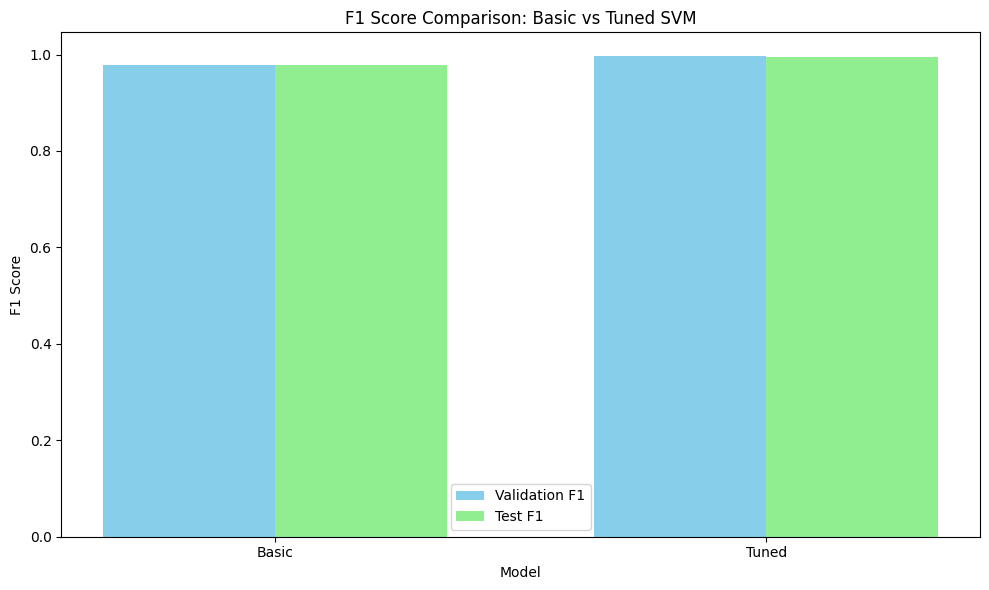

In [45]:
# Visualization: Bar Chart for F1 Score Comparison (Val and Test)
plt.figure(figsize=(10, 6))
x = np.arange(len(['Basic', 'Tuned']))
width = 0.35

plt.bar(x - width/2, [val_metrics['F1 Score'], val_metrics_tuned['F1 Score']], width, label='Validation F1', color='skyblue')
plt.bar(x + width/2, [test_metrics_basic['F1 Score'], test_metrics_tuned['F1 Score']], width, label='Test F1', color='lightgreen')

plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison: Basic vs Tuned SVM')
plt.xticks(x, ['Basic', 'Tuned'])
plt.legend()
plt.tight_layout()
plt.show()

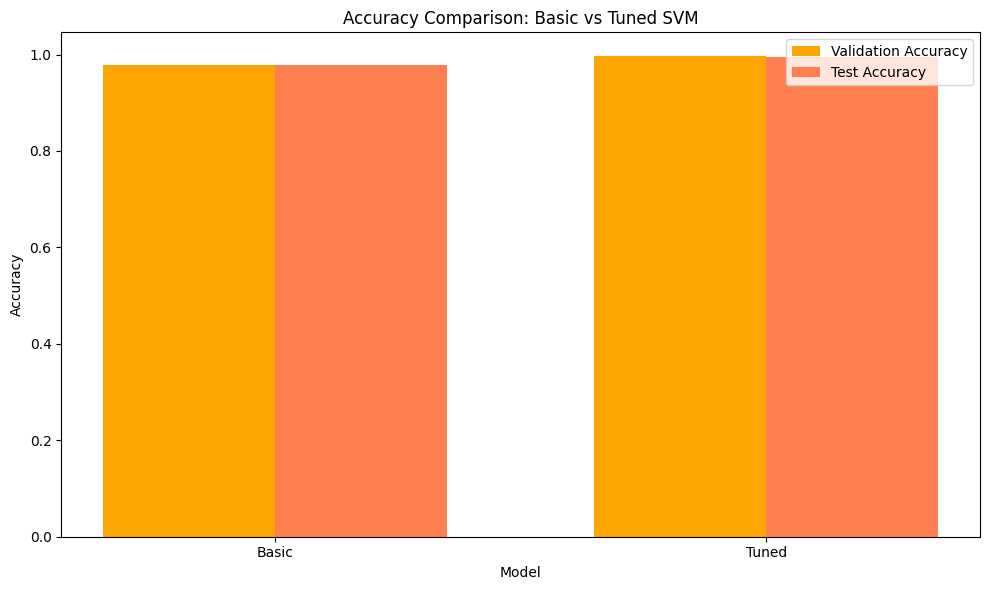

In [46]:
# Visualization: Bar Chart for Accuracy Comparison (Val and Test)
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, [val_metrics['Accuracy'], val_metrics_tuned['Accuracy']], width, label='Validation Accuracy', color='orange')
plt.bar(x + width/2, [test_metrics_basic['Accuracy'], test_metrics_tuned['Accuracy']], width, label='Test Accuracy', color='coral')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison: Basic vs Tuned SVM')
plt.xticks(x, ['Basic', 'Tuned'])
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# Full Metrics Table for Tuned Model (Final Selection)
print("\nFinal Tuned Model Performance:")
print("Training Metrics:")
for metric, value in train_metrics_tuned.items():
    print(f"  {metric}: {value:.4f}")

print("\nValidation Metrics:")
for metric, value in val_metrics_tuned.items():
    print(f"  {metric}: {value:.4f}")

print("\nTest Metrics:")
for metric, value in test_metrics_tuned.items():
    print(f"  {metric}: {value:.4f}")


Final Tuned Model Performance:
Training Metrics:
  Accuracy: 0.9969
  Precision: 0.9981
  Recall: 0.9956
  F1 Score: 0.9968
  AUC: 1.0000

Validation Metrics:
  Accuracy: 0.9962
  Precision: 0.9972
  Recall: 0.9953
  F1 Score: 0.9962
  AUC: 0.9999

Test Metrics:
  Accuracy: 0.9953
  Precision: 0.9935
  Recall: 0.9972
  F1 Score: 0.9953
  AUC: 0.9998


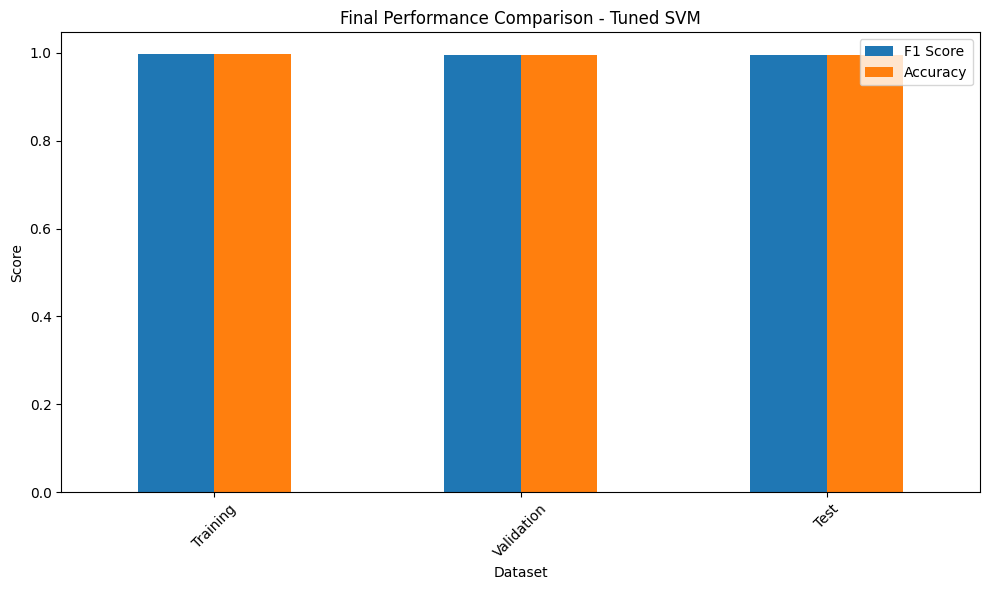

In [48]:
# Visualization: Train/Val/Test Comparison for Tuned Model (F1 and Accuracy)
final_comparison_data = {
    'Dataset': ['Training', 'Validation', 'Test'],
    'F1 Score': [train_metrics_tuned['F1 Score'], val_metrics_tuned['F1 Score'], test_metrics_tuned['F1 Score']],
    'Accuracy': [train_metrics_tuned['Accuracy'], val_metrics_tuned['Accuracy'], test_metrics_tuned['Accuracy']]
}
final_df = pd.DataFrame(final_comparison_data)
final_df.set_index('Dataset').plot(kind='bar', figsize=(10, 6))
plt.title('Final Performance Comparison - Tuned SVM')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

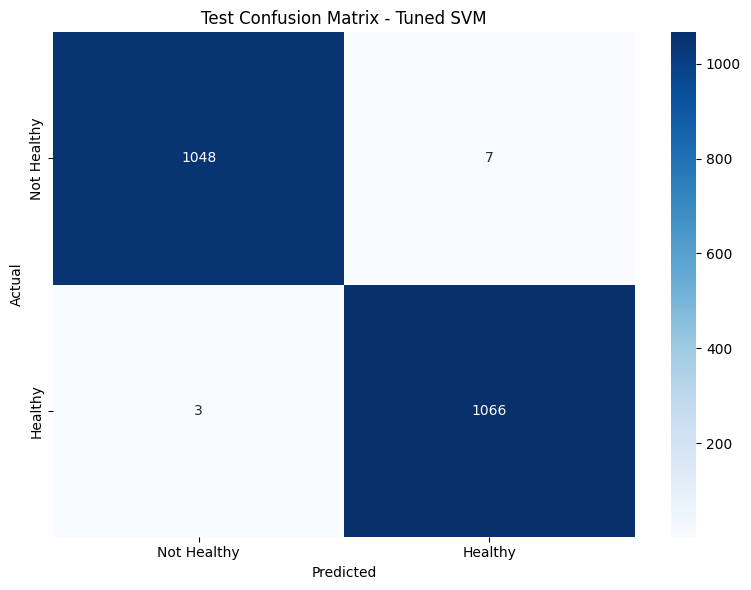

In [49]:
# Confusion Matrix for Tuned Model (Test Set)
cm_test = confusion_matrix(y_test, y_test_pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Healthy', 'Healthy'],
            yticklabels=['Not Healthy', 'Healthy'])
plt.title('Test Confusion Matrix - Tuned SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

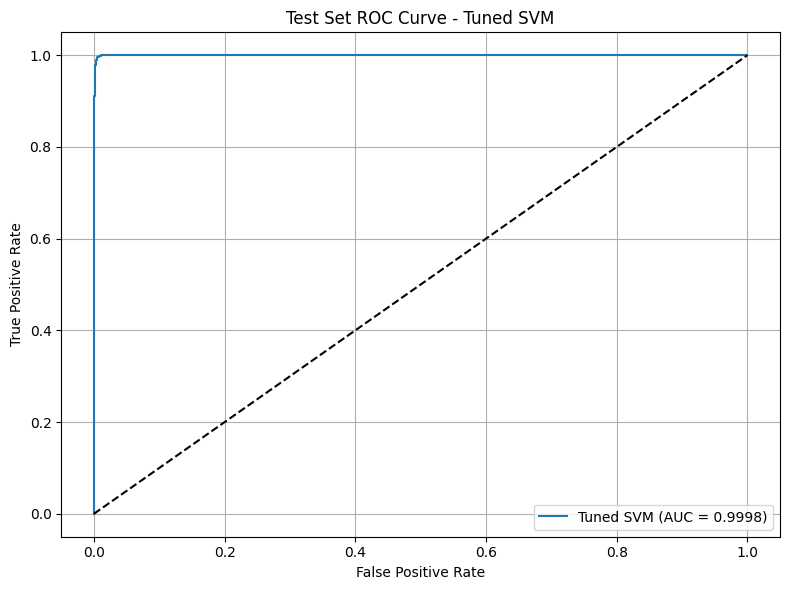

In [50]:
# ROC Curve for Tuned Model (Test Set)
fpr, tpr, _ = roc_curve(y_test, best_svm_model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Tuned SVM (AUC = {test_metrics_tuned["AUC"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test Set ROC Curve - Tuned SVM')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
# Save tuned model
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)
model_filename = os.path.join(models_dir, "tuned_svm_model.pkl")
with open(model_filename, "wb") as f:
    pickle.dump(best_svm_model, f)
print(f"\nTuned model saved to {model_filename}")

print("\nModel comparison and final evaluation complete!")


Tuned model saved to ../models/tuned_svm_model.pkl

Model comparison and final evaluation complete!
